=== ROC-AUC Score 결과 ===
RandomForest ROC-AUC: 0.8344
XGBoost      ROC-AUC: 0.8208
LightGBM     ROC-AUC: 0.8152


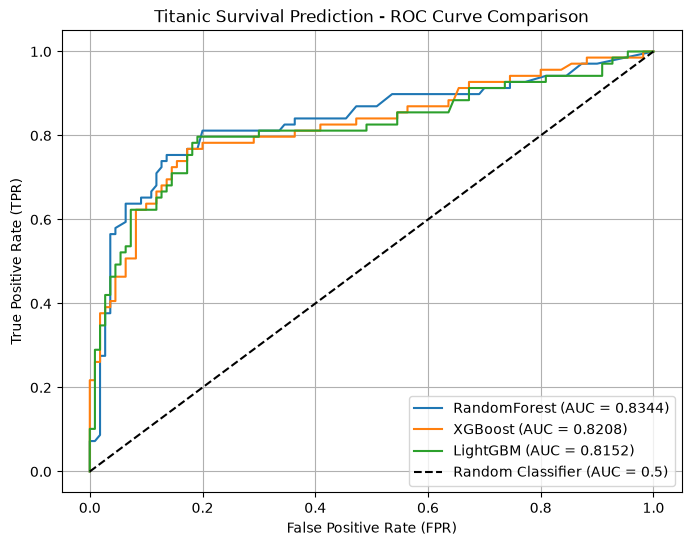

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

# 분류 모델 불러오기
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

titanic = sns.load_dataset('titanic')

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = titanic[features + ['survived']].copy()

df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

plt.figure(figsize=(8, 6))

print("=== ROC-AUC Score 결과 ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"{name:12s} ROC-AUC: {auc_score:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Titanic Survival Prediction - ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()